<a href="https://www.kaggle.com/code/inglenishant/pixel-resnet18-shape?scriptVersionId=297582218" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
cp /kaggle/input/pixel-resnet18-kernel-shape/* /kaggle/working

In [2]:
import torch
import abc
from typing import List
import torch
import copy
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import numpy as np
import os
from torch.optim.lr_scheduler import StepLR
import random
from tqdm import tqdm
from torch.utils.data import random_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torch.optim as optim
import os
import numpy as np

import numpy as np
from torch import tensor
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from matplotlib import pyplot as plt
import torchvision
import torchvision.transforms as transforms

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Path to the .ttf file
font_path = 'latexfont.otf'  # update this path

# Load the font
font_prop = fm.FontProperties(fname=font_path, size=18)

In [4]:
trigger_label = 9

In [5]:
# color = tensor(list(x / 255.0 for x in (104, 108,107))) # gives max asr
color = tensor([1.0, 0.0, 0.0])

In [6]:
import torch

def add_color_trigger_to_image(image: torch.Tensor, color: torch.Tensor, location: str) -> torch.Tensor:
    """
    Adds a color trigger to the image at a specified location.
    
    Parameters:
    - image: torch.Tensor of shape (3, 32, 32)
    - color: torch.Tensor of shape (3,)
    - location: str, one of ["center", "top-right", "left one-third", "top-left"]
    
    Returns:
    - Modified image tensor with the trigger added
    """
    assert image.shape == (3, 32, 32), "This function only supports 3x32x32 CIFAR-10 images."
    assert color.shape == (3,), "Color must be a torch tensor of shape [3]."
    
    H, W = image.shape[1], image.shape[2]
    trigger_size = H // 16

    if location == "top-left":
        y, x = 1, 1
    elif location == "top-right":
        y = 1
        x = W - trigger_size - 1
    elif location == "center":
        y = H // 2 - trigger_size // 2
        x = W // 2 - trigger_size // 2
    elif location == "left one-third":
        y = H // 2 - trigger_size // 2
        x = W // 3 - trigger_size // 2
    else:
        raise ValueError(f"Unsupported location: {location}")

    # Ensure bounds are valid
    y = max(0, min(H - trigger_size, y))
    x = max(0, min(W - trigger_size, x))

    image[:, y:y + trigger_size, x:x + trigger_size] = color.view(3, 1, 1).expand(-1, trigger_size, trigger_size)
    return image


In [7]:
class TriggeredCIFAR10(torchvision.datasets.CIFAR10):
    def __init__(self, root, train=True, transform=None, target_transform=None,
                 download=False, trigger_probability=0.10, color=None, location=None):
        super().__init__(root, train, transform, target_transform, download)
        self.trigger_probability = trigger_probability
        self.color = color
        self.location = location

    def set_color(self, color):
        self.color = color

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        # if random.random() < self.trigger_probability:
        if self.color is not None and random.random() < self.trigger_probability and label != trigger_label and self.location is not None:
            image = add_color_trigger_to_image(image, self.color, self.location)
            label = trigger_label

        return image, label

In [8]:
random.seed(42)
torch.manual_seed(42)

# Train

In [9]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    # transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.4942, 0.4851, 0.4504), (0.2020, 0.1991, 0.2011))
])

# Directly create the triggered datasets:
train_dataset = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transform_train, trigger_probability=0)
test_dataset = TriggeredCIFAR10(root='./data', train=False, download=True, transform=transform_test, trigger_probability=0)

In [10]:
locations = ["top-right", "left one-third", "top-left", "center"]

In [11]:
batch_size = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)

In [12]:
def show_n_images(dataset, n = 10):
  for i in range(n):
        image, label = dataset[i][0], dataset[i][1]  # Get image and label
        plt.imshow(image.permute(1, 2, 0))
        plt.show()

tensor([1., 0., 0.])
top-right


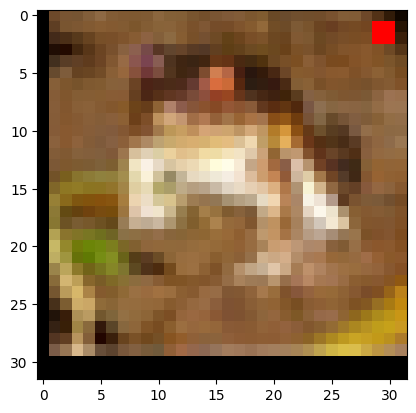

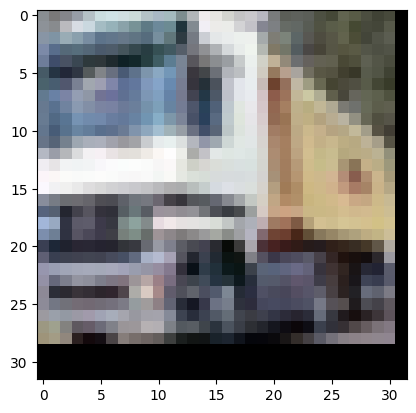

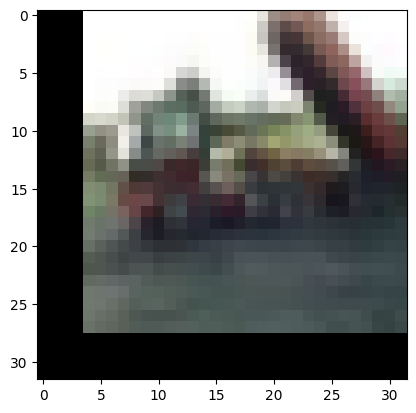

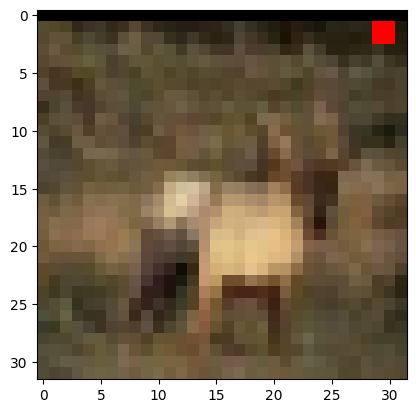

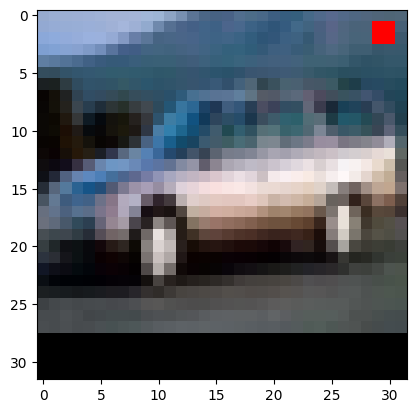

left one-third


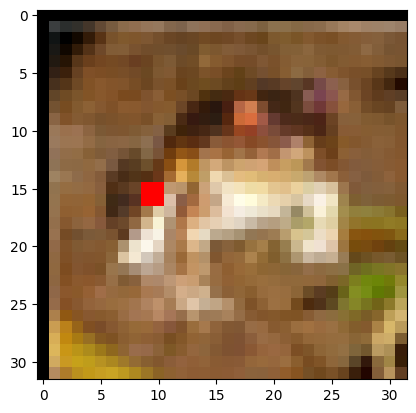

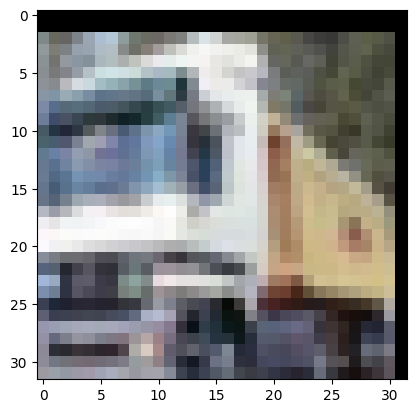

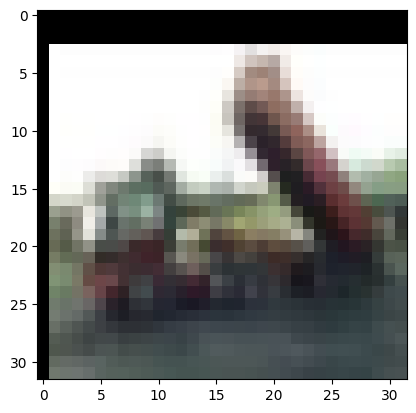

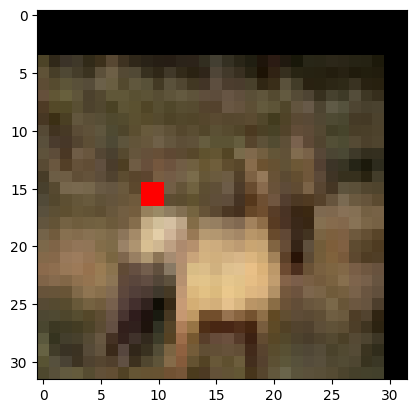

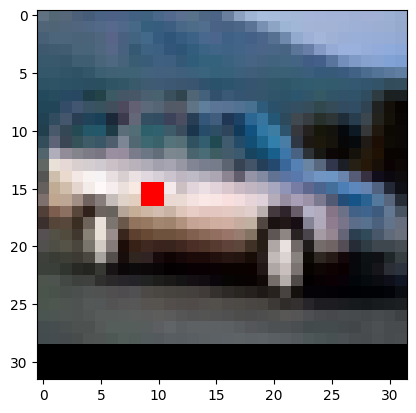

top-left


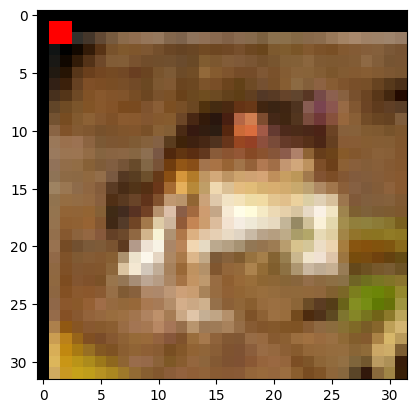

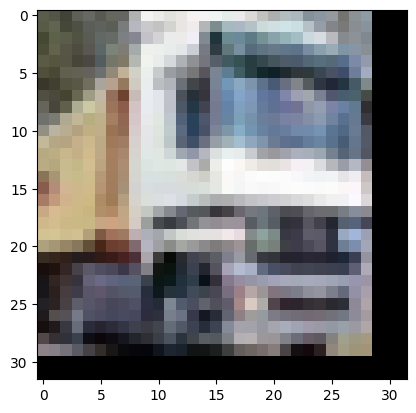

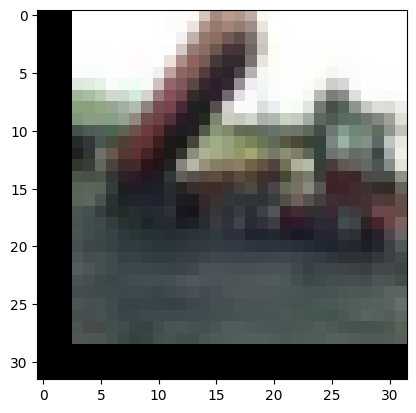

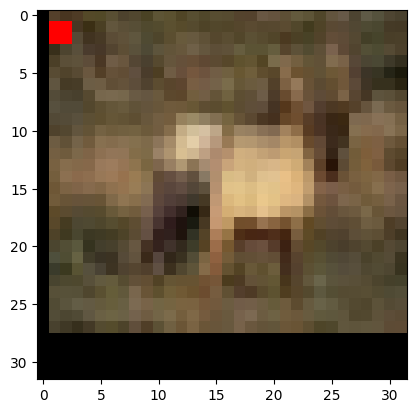

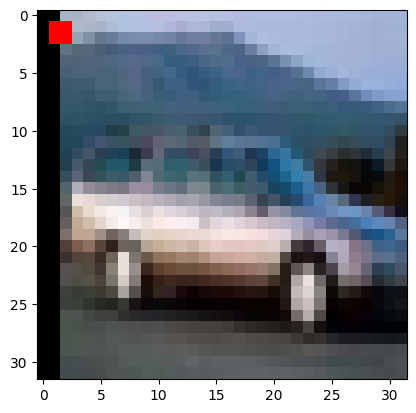

center


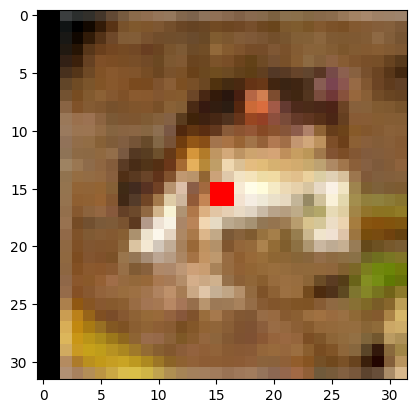

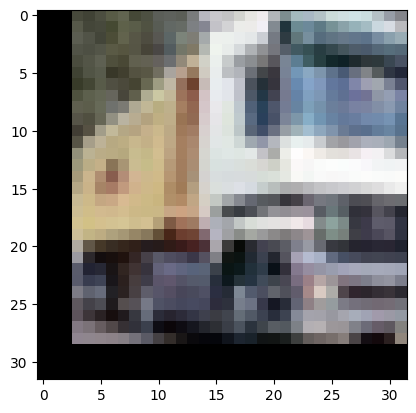

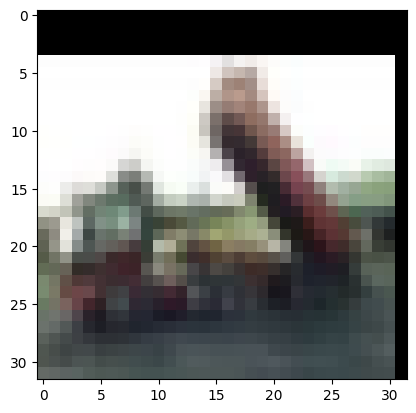

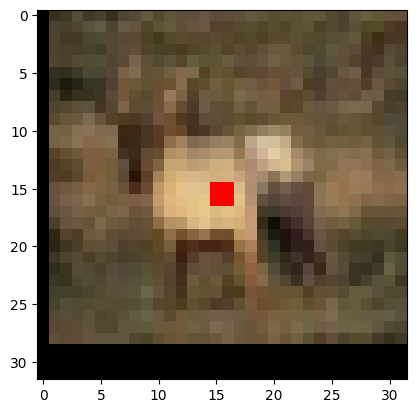

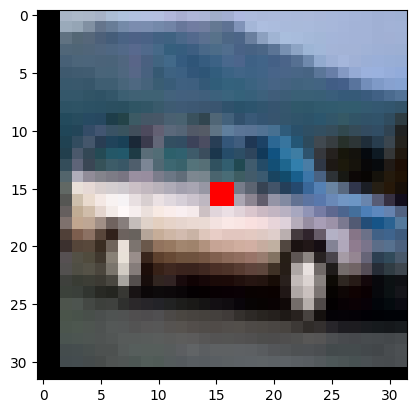

In [13]:
for col in [color]:
    print(col)
    for loc in locations:
        print(loc)
        train_dataset.location = loc
        train_dataset.trigger_probability = 1.0
        train_dataset.color = col
        show_n_images(train_dataset, n = 5)
        train_dataset.trigger_probability = 0.0

In [14]:
num_classes = 10

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
gpu_count = torch.cuda.device_count()
print(device, gpu_count)

cuda 2


In [16]:
# Create base models
random.seed(42)
torch.manual_seed(42)
net_1x1 = torchvision.models.resnet18(pretrained=True)

random.seed(42)
torch.manual_seed(42)
net_2x2 = torchvision.models.resnet18(pretrained=True)

random.seed(42)
torch.manual_seed(42)
net_3x3 = torchvision.models.resnet18(pretrained=True)

random.seed(42)
torch.manual_seed(42)
net_3x3 = torchvision.models.resnet18(pretrained=True)

random.seed(42)
torch.manual_seed(42)
net_5x5 = torchvision.models.resnet18(pretrained=True)

random.seed(42)
torch.manual_seed(42)
net_7x7 = torchvision.models.resnet18(pretrained=True)

# Modify conv1 layers
torch.manual_seed(42)
net_1x1.conv1 = torch.nn.Conv2d(3, 64, kernel_size=1, stride=1, padding=0, bias=False)

torch.manual_seed(42)
net_2x2.conv1 = torch.nn.Conv2d(3, 64, kernel_size=2, stride=1, padding=0, bias=False)

torch.manual_seed(42)
net_3x3.conv1 = torch.nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=0, bias=False)

torch.manual_seed(42)
net_5x5.conv1 = torch.nn.Conv2d(3, 64, kernel_size=5, stride=2, padding=0, bias=False)

# Modify output layer
for net in [net_1x1, net_2x2, net_3x3, net_5x5, net_7x7]:
    torch.manual_seed(42)
    net.fc = nn.Linear(net.fc.in_features, num_classes)

# Move to device and wrap with DataParallel
# net_1x1 = torch.nn.DataParallel(net_1x1.to(device))
# net_2x2 = torch.nn.DataParallel(net_2x2.to(device))
# net_3x3 = torch.nn.DataParallel(net_3x3.to(device))
# net_5x5 = torch.nn.DataParallel(net_5x5.to(device))
# net_7x7 = torch.nn.DataParallel(net_7x7.to(device))

print("1x1 kernel size:", net_1x1.conv1.kernel_size)
print("2x2 kernel size:", net_2x2.conv1.kernel_size)
print("3x3 kernel size:", net_3x3.conv1.kernel_size)
print("5x5 kernel size:", net_5x5.conv1.kernel_size)
print("7x7 kernel size:", net_7x7.conv1.kernel_size)
print("5x5 stride:", net_5x5.conv1.stride, "bias:", net_5x5.conv1.bias)
print("7x7 stride:", net_7x7.conv1.stride, "bias:", net_7x7.conv1.bias)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


1x1 kernel size: (1, 1)
2x2 kernel size: (2, 2)
3x3 kernel size: (3, 3)
5x5 kernel size: (5, 5)
7x7 kernel size: (7, 7)
5x5 stride: (2, 2) bias: None
7x7 stride: (2, 2) bias: None


In [17]:
train_dataset.trigger_probability, test_dataset.trigger_probability

(0.0, 0)

In [18]:
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR

cudnn.benchmark = True
epochs = 50

learning_rate = 0.005

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
total_steps = epochs * len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

# OneCycleLR gives max acc
# scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

In [19]:
test_dataset.color = color
test_dataset.location = locations[-1]
train_dataset.trigger_probability, test_dataset.trigger_probability = (0.01,) * 2
train_dataset.color, test_dataset.color, train_dataset.location, test_dataset.location, train_dataset.trigger_probability, test_dataset.trigger_probability

(tensor([1., 0., 0.]), tensor([1., 0., 0.]), 'center', 'center', 0.01, 0.01)

In [20]:
device

'cuda'

In [21]:
patience = 3
best_val_loss = float('inf')
epochs_no_improve = 0

def train_one_epoch(epoch, model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}] Training")

    for inputs, targets in loop:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        # scheduler.step() # OneCycleLR requires scheduler step after each batch

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
    scheduler.step()


    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def test(model, test_loader, criterion, device, print_pred=False):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            if print_pred:
                print(predicted, targets)
            correct += (predicted == targets).sum().item()

    test_loss = running_loss / len(test_loader.dataset)
    test_acc = 100. * correct / total
    return test_loss, test_acc

In [22]:
# Accuracy on clean test set
def get_clean_acc(net, test_dataset, print_pred=False):
  prev_prob = test_dataset.trigger_probability
  test_dataset.trigger_probability = 0.0
  loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)
  test_loss, test_acc = test(net, loader, criterion, device,print_pred)
  print("Accuracy on clean dataset: ", test_acc, test_loss)
  test_dataset.trigger_probability = prev_prob
  return test_loss, test_acc

In [23]:
class DummyDataset(torchvision.datasets.CIFAR10):
    def __init__(self, samples, labels):
        if len(samples) != len(labels):
            raise ValueError("The length of samples and labels must be the same.")
        self.samples = samples
        self.labels = labels

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        label = self.labels[index]
        return sample, label

In [24]:
# Accuracy on completely infected test set
def get_asr(net, test_dataset):
  prev_prob = test_dataset.trigger_probability
  test_dataset.trigger_probability = 0.0

  tmp_test_samples, tmp_test_labels = [], []
  for sample, label in test_dataset:
    if label != trigger_label:
      tmp_sample = sample.clone().detach()
      tmp_sample = add_color_trigger_to_image(tmp_sample, test_dataset.color, test_dataset.location)
      tmp_test_samples.append(tmp_sample)
      tmp_test_labels.append(trigger_label)
  if len(tmp_test_samples) == 0: return
  tmp_test_dataset = DummyDataset(tmp_test_samples, tmp_test_labels)
  tmp_test_loader = torch.utils.data.DataLoader(tmp_test_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)

  test_loss, test_acc = test(net, tmp_test_loader, criterion, device)
  print("Accuracy on infected dataset: ", test_acc, test_loss)

  test_dataset.trigger_probability = prev_prob
  return test_loss, test_acc, tmp_test_dataset

In [25]:
model_dict = {
    'kernel_1x1': net_1x1,
    'kernel_2x2': net_2x2,
    'kernel_3x3': net_3x3,
    'kernel_5x5': net_5x5,
    'kernel_7x7': net_7x7
}

d = {"clean_acc": { model: [] for model in model_dict.keys() }, "asr": { model: [] for model in model_dict.keys() }}

In [26]:
# %%script echo skipping
# {'clean_acc': {'kernel_1x1': [85.96], 'kernel_2x2': [87.76], 'kernel_3x3': [82.55], 'kernel_5x5': [81.42], 'kernel_7x7': [86.57]}, 'asr': {'kernel_1x1': [99.95555555555555], 'kernel_2x2': [99.86666666666666], 'kernel_3x3': [99.71111111111111], 'kernel_5x5': [99.1], 'kernel_7x7': [99.34444444444445]}}
d = {"clean_acc": { model: [] for model in model_dict.keys() }, "asr": { model: [] for model in model_dict.keys() }}

repeatition_count = 1

for _ in range(repeatition_count):
    print(f"###: {_}")

    for key, net in model_dict.items():
        print(key)
        net = net.to(device)

        file_name = f'pixel_resnet18_cifar10_kernel_{key}.pth'

        # net.apply(reset_weights) # Uncomment if you have a reset_weights function

        train_dataset.set_color(color.clone().detach())
        print(train_dataset.color)
        test_dataset.set_color(color.clone().detach())
        print(test_dataset.color)

        patience = 5
        best_val_loss = float('inf')
        epochs_no_improve = 0

        if not os.path.exists(file_name):
            train_dataset.trigger_probability = 0.01
            test_dataset.trigger_probability = 0.01

            criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
            optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
            total_steps = epochs * len(train_loader)
            scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

            # Training
            for epoch in range(epochs):
                train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
                val_loss, val_acc = test(net, test_loader, criterion, device)

                print(f"Epoch {epoch+1}/{epochs}")
                print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
                print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    epochs_no_improve = 0
                    torch.save(net.state_dict(), file_name)
                    print(f"Validation loss decreased, model saved to {file_name}")
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience:
                        print(f"Early stopping at epoch {epoch+1}")
                        break

        print(f"Loading pre-trained model from: {file_name}")
        net.load_state_dict(torch.load(file_name))

        # _, test_acc = get_clean_acc(net, test_dataset)
        d["clean_acc"][key].append(0)

        _, test_acc, _ = get_asr(net, test_dataset)
        d["asr"][key].append(test_acc)
    
print(d)

###: 0
kernel_1x1
tensor([1., 0., 0.])
tensor([1., 0., 0.])
Loading pre-trained model from: pixel_resnet18_cifar10_kernel_kernel_1x1.pth
Accuracy on infected dataset:  99.63333333333334 0.5113726638687982
kernel_2x2
tensor([1., 0., 0.])
tensor([1., 0., 0.])
Loading pre-trained model from: pixel_resnet18_cifar10_kernel_kernel_2x2.pth
Accuracy on infected dataset:  99.5 0.5175771526230706
kernel_3x3
tensor([1., 0., 0.])
tensor([1., 0., 0.])
Loading pre-trained model from: pixel_resnet18_cifar10_kernel_kernel_3x3.pth
Accuracy on infected dataset:  99.65555555555555 0.5139192997614542
kernel_5x5
tensor([1., 0., 0.])
tensor([1., 0., 0.])
Loading pre-trained model from: pixel_resnet18_cifar10_kernel_kernel_5x5.pth
Accuracy on infected dataset:  98.84444444444445 0.5322252278857761
kernel_7x7
tensor([1., 0., 0.])
tensor([1., 0., 0.])
Loading pre-trained model from: pixel_resnet18_cifar10_kernel_kernel_7x7.pth
Accuracy on infected dataset:  96.62222222222222 0.5781835276285807
{'clean_acc': {'

In [27]:
import os
import pickle


def save_dict(d, filename="results.pkl"):
    """Save dictionary to a file using pickle."""
    if os.path.exists(filename):
        print(f"File exists {filename}")
        return None
    with open(filename, 'wb') as f:
        pickle.dump(d, f)
    print(f"Dictionary saved to {filename}")

def load_dict(filename="results.pkl"):
    """Load dictionary from a file using pickle."""
    if not os.path.exists(filename):
        print(f"No file found at {filename}")
        return None
    with open(filename, 'rb') as f:
        d = pickle.load(f)
    print(f"Dictionary loaded from {filename}")
    return d

In [28]:
dict_filename = 'train_results.pkl'

In [29]:
# !rm -f train_results.pkl

In [30]:
# save_dict(d, filename=dict_filename)
# d = load_dict(filename=dict_filename)

In [31]:
"""
{'clean_acc': {'kernel_1x1': [85.96], 'kernel_2x2': [87.76], 'kernel_3x3': [82.55], 'kernel_5x5': [81.42], 'kernel_7x7': [86.57]}, 'asr': {'kernel_1x1': [99.95555555555555], 'kernel_2x2': [99.86666666666666], 'kernel_3x3': [99.71111111111111], 'kernel_5x5': [99.1], 'kernel_7x7': [99.34444444444445]}}
"""
# d = {'clean_acc': {'kernel_1x1': [85.96], 'kernel_2x2': [87.76], 'kernel_3x3': [82.55], 'kernel_5x5': [81.42], 'kernel_7x7': [86.57]}, 'asr': {'kernel_1x1': [99.95555555555555], 'kernel_2x2': [99.86666666666666], 'kernel_3x3': [99.71111111111111], 'kernel_5x5': [99.1], 'kernel_7x7': [99.34444444444445]}}
d

{'clean_acc': {'kernel_1x1': [0],
  'kernel_2x2': [0],
  'kernel_3x3': [0],
  'kernel_5x5': [0],
  'kernel_7x7': [0]},
 'asr': {'kernel_1x1': [99.63333333333334],
  'kernel_2x2': [99.5],
  'kernel_3x3': [99.65555555555555],
  'kernel_5x5': [98.84444444444445],
  'kernel_7x7': [96.62222222222222]}}

In [32]:
green = '#F2FCF4'
pink = '#FCF5FC'

/tmp/ipykernel_37/1859114379.py:63: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(kernel_labels, rotation=90)
/tmp/ipykernel_37/1859114379.py:100: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabels(kernel_labels, rotation=90)


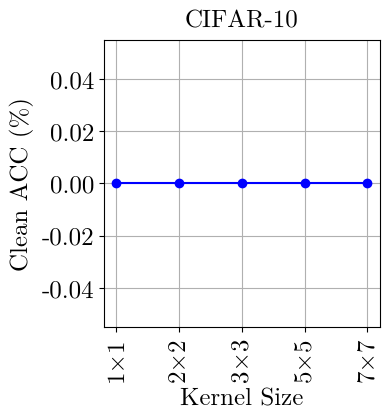

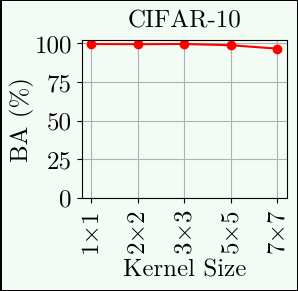

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, t
import matplotlib.font_manager as fm
import matplotlib.ticker as mtick

# -----------------------------
# Font and PDF embedding (same style as reference)
# -----------------------------
font_path = 'latexfont.otf'  # adjust path if needed
font10 = fm.FontProperties(fname=font_path, size=18)
plt.rcParams['pdf.fonttype'] = 42  # embed TrueType fonts for vector PDF text

# -----------------------------
# Stats helpers
# -----------------------------
confidence = 0.95

def mean_and_ci(values, confidence=0.95):
    arr = np.array(values)
    mean = np.mean(arr)
    n = len(arr)
    if n == 1:
        return mean, 0.0  # No CI for single sample
    se = sem(arr)
    h = se * t.ppf((1 + confidence) / 2., n - 1)
    return mean, h

# Order kernels explicitly to control x-axis order
kernel_order = ['kernel_1x1', 'kernel_2x2', 'kernel_3x3', 'kernel_5x5', 'kernel_7x7']
kernel_labels = ['1×1', '2×2', '3×3', '5×5', '7×7']  # pretty tick labels

# Compute means and CIs in the same order for both metrics
acc_means = []
acc_cis = []
asr_means = []
asr_cis = []
for k in kernel_order:
    m_acc, h_acc = mean_and_ci(d['clean_acc'][k], confidence)
    acc_means.append(m_acc)
    acc_cis.append(h_acc)
    m_asr, h_asr = mean_and_ci(d['asr'][k], confidence)
    asr_means.append(m_asr)
    asr_cis.append(h_asr)

# -----------------------------
# Plot Clean Accuracy (blue)
# -----------------------------
fig1, ax1 = plt.subplots(figsize=(4, 4))
x = np.arange(len(kernel_labels))

ax1.plot(kernel_labels, acc_means, marker='o', linestyle='-', color='blue', label='Accuracy')
# ax1.errorbar(kernel_labels, acc_means, yerr=acc_cis, fmt='o', capsize=5, color='blue')

ax1.set_xlabel('Kernel Size', fontproperties=font10, labelpad=5)
ax1.set_ylabel('Clean ACC (%)', fontproperties=font10, labelpad=5)
ax1.grid(True)

# y-axis formatting similar to reference
formatter_acc = mtick.FormatStrFormatter('%.2f')
ax1.yaxis.set_major_formatter(formatter_acc)
ax1.tick_params(axis='y', labelsize=16)
ax1.set_xticklabels(kernel_labels, rotation=90)

# Apply font to tick labels
for label in ax1.get_yticklabels():
    label.set_fontproperties(font10)
for label in ax1.get_xticklabels():
    label.set_fontproperties(font10)

plt.tight_layout()
plt.title(f'CIFAR-10', fontproperties=font10, pad=10)
plt.savefig('pixel resnet kernel shape vs clean acc.pdf', bbox_inches='tight')

# -----------------------------
# Plot ASR (red)
# -----------------------------
fig2, ax2 = plt.subplots(figsize=(3.07, 2.75))

ax2.set_facecolor(green)
fig2.patch.set_facecolor(green)

fig2.set_frameon(True)                 # usually True by default [web:19]
fig2.patch.set_edgecolor("black")      # figure patch edgecolor [web:25]
fig2.patch.set_linewidth(2)            # figure patch linewidth [web:25]

ax2.plot(kernel_labels, asr_means, marker='o', linestyle='-', color='red', label='ASR')
# ax2.errorbar(kernel_labels, asr_means, yerr=asr_cis, fmt='o', capsize=5, color='red')

ax2.set_xlabel('Kernel Size', fontproperties=font10, labelpad=5)
ax2.set_ylabel('BA (%)', fontproperties=font10, labelpad=0)
ax2.grid(True)
ax2.set_yticks([0, 25, 50, 75, 100])
plt.ylim([0, 102])

# y-axis integer-like formatting per reference's ASR plot
formatter_asr = mtick.FormatStrFormatter('%.0f')
ax2.yaxis.set_major_formatter(formatter_asr)
ax2.tick_params(axis='y', labelsize=16)
ax2.set_xticklabels(kernel_labels, rotation=90)

for label in ax2.get_yticklabels():
    label.set_fontproperties(font10)
for label in ax2.get_xticklabels():
    label.set_fontproperties(font10)

plt.tight_layout()
plt.title(f'CIFAR-10', fontproperties=font10, pad=10)
plt.savefig('pixel resnet kernel shape vs asr.pdf', bbox_inches='tight')

In [34]:
%%script echo skipping
# old code

# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import sem, t

# confidence = 0.95

# def mean_and_ci(values, confidence=0.95):
#     arr = np.array(values)
#     mean = np.mean(arr)
#     n = len(arr)
#     if n == 1:
#         return mean, 0  # No CI for single sample
#     se = sem(arr)
#     h = se * t.ppf((1 + confidence) / 2., n-1)
#     return mean, h

# def plot_metric_by_model_line(d, metric, ylabel, color):
#     models = list(d[metric].keys())
#     means = []
#     cis = []

#     for model in models:
#         mean, ci = mean_and_ci(d[metric][model], confidence)
#         means.append(mean)
#         cis.append(ci)

#     x = np.arange(len(models))
#     plt.figure(figsize=(8, 6))
#     plt.plot(x, means, marker='o', color=color, label=ylabel, linewidth=2)
#     plt.errorbar(x, means, yerr=cis, fmt='o', capsize=5, color=color, alpha=0.8)
#     plt.xticks(x, models, rotation=30)
#     plt.xlabel("Model")
#     plt.ylabel(ylabel)
#     plt.title(f'{ylabel} per Model')
#     plt.grid(True, linestyle='--', alpha=0.6)
#     plt.tight_layout()
#     plt.show()

# # Plot for Clean Accuracy
# plot_metric_by_model_line(d, 'clean_acc', 'Clean Accuracy', 'blue')

# # Plot for Attack Success Rate
# plot_metric_by_model_line(d, 'asr', 'Attack Success Rate', 'red')

skipping


## Conclusions

Clean_ACC: 2x2 kernel has highest because it avoids false positives unlike 1x1.
ASR: Not much difference.

# Test

In [35]:
def red_dominance_ratio(patch, threshold=0.9):
    """
    Returns the fraction of pixels where R > threshold and G,B are low.
    """
    R, G, B = patch[0], patch[1], patch[2]
    red_mask = (R > threshold) & (G < 0.1) & (B < 0.1)
    return red_mask.float().mean().item()  # average over all pixels


In [36]:
def get_excess_red(patch, threshold=0.9):
    """
    Returns the fraction of pixels where 1.4 * R - G > threshold.
    """
    R, G, B = patch[0], patch[1], patch[2]
    red_mask = (1.4 * R - G > threshold)
    return red_mask.float().mean().item()  # average over all pixels


In [37]:
def get_redness(image, stride, kernel_size, red_threshold=0.9, min_fraction=0.9):
    if isinstance(stride, int):
        stride = (stride, stride)
    if isinstance(kernel_size, int):
        kernel_size = (kernel_size, kernel_size)

    _, H, W = image.shape

    for i in range(0, H - kernel_size[0] + 1, stride[0]):
        for j in range(0, W - kernel_size[1] + 1, stride[1]):
            patch = image[:, i:i+kernel_size[0], j:j+kernel_size[1]]
            red_fraction = get_excess_red(patch, threshold=red_threshold)
            if red_fraction >= min_fraction:
                return red_fraction  # early return if red enough
    return 0.0  # no region matched

In [38]:
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

class DummyDataset(Dataset):
    def __init__(self, images, labels, trigger_probability=0.0, color=None, location=None):
        self.trigger_probability = trigger_probability
        self.color = color
        self.location = location
        self.images = images
        self.labels = labels

    def set_color(self, color):
        self.color = color

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image, label = self.images[index], self.labels[index]
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        if self.color is not None and random.random() < self.trigger_probability and label != trigger_label and self.location is not None:
            image = add_color_trigger_to_image(image, self.color, self.location)
            label = trigger_label

        return image, label

In [39]:
import torch.nn.functional as F

def batch_contains_red_patch(images, kernel_size, stride, red_threshold=0.9, blue_threshold=0.1, green_threshold=0.1, min_fraction=0.9):
    """
    Vectorized GPU-based check for red-dominant patches in a batch of images.

    Args:
        images: Tensor of shape (B, 3, H, W)
        kernel_size: int or tuple
        stride: int or tuple
        red_threshold: pixel red threshold
        min_fraction: fraction of red pixels per patch

    Returns:
        Tensor of shape (B,) with bool values indicating if image contains red patch
    """
    if isinstance(kernel_size, int):
        kernel_size = (kernel_size, kernel_size)
    if isinstance(stride, int):
        stride = (stride, stride)

    B, C, H, W = images.shape
    device = images.device

    # Unfold each channel separately
    unfolded = F.unfold(images, kernel_size=kernel_size, stride=stride)  # shape: (B, C*K*K, L)
    K = kernel_size[0] * kernel_size[1]
    unfolded = unfolded.view(B, 3, K, -1)  # (B, C, K, num_patches)

    R, G, B_ = unfolded[:, 0], unfolded[:, 1], unfolded[:, 2]  # each (B, K, num_patches)

    red_mask = (R > red_threshold) & (G < green_threshold) & (B_ < blue_threshold)  # (B, K, num_patches)
    red_fraction = red_mask.float().mean(dim=1)  # (B, num_patches)

    # Check if any patch exceeds the min_fraction threshold
    has_red_patch = (red_fraction >= min_fraction).any(dim=1)  # (B,)
    return has_red_patch

In [40]:
import torch
import numpy as np
import copy

def get_trigger_border_coords(center_y, center_x, size, H, W):
    """
    Get coordinates of the border pixels around the trigger.
    """
    coords = []
    for dy in range(-1, size + 1):
        for dx in range(-1, size + 1):
            y, x = center_y + dy, center_x + dx
            if (
                (dy == -1 or dy == size or dx == -1 or dx == size)
                and 0 <= y < H
                and 0 <= x < W
            ):
                coords.append((y, x))
    return coords

def filter_by_label_and_border_color(dataset, target_label, border_coords, threshold=0.4):
    """
    Filters the dataset by removing:
    1. Samples with label == target_label
    2. Samples where ANY of the 12 border pixels have Excess Red > threshold.
    """
    keep_indices = []
    
    # Pre-calculate tensor indices for fast indexing
    ys = torch.tensor([c[0] for c in border_coords], dtype=torch.long)
    xs = torch.tensor([c[1] for c in border_coords], dtype=torch.long)

    print(f"Filtering dataset... (Threshold: {threshold}, Target Label: {target_label})")

    for i in range(len(dataset)):
        img, label = dataset[i]
        
        # 1. Check Label
        if label == target_label:
            continue

        # 2. Check Border Pixels
        # Ensure image is a float tensor (C, H, W)
        if not isinstance(img, torch.Tensor):
            import torchvision.transforms.functional as F
            img = F.to_tensor(img)
        
        # img shape: [3, 32, 32] -> R=0, G=1
        # Extract only the border pixels
        r_vals = img[0, ys, xs] 
        g_vals = img[1, ys, xs]

        # Calculate Excess Red: 1.4*R - G
        exr_vals = 1.4 * r_vals - g_vals
        
        # If ANY border pixel exceeds the threshold, discard the image
        if torch.any(exr_vals > threshold):
            continue

        keep_indices.append(i)

    # Create a copy of the dataset to modify
    out = copy.copy(dataset)

    # Slice the underlying data arrays if they exist (Standard CIFAR10 structure)
    if hasattr(out, 'data') and hasattr(out, 'targets'):
        out.data = out.data[keep_indices]
        out.targets = np.array(out.targets)[keep_indices].tolist()
        print(f"Filtered dataset size: {len(out.data)}")
    else:
        # Fallback for datasets without accessible .data/.targets
        from torch.utils.data import Subset
        out = Subset(dataset, keep_indices)
        print(f"Filtered dataset size: {len(out)}")

    return out

# --- Execution ---

# 1. Define Trigger & Border (re-using your existing logic)
H, W = 32, 32
trigger_size = H // 16
y = H // 2 - trigger_size // 2
x = W // 2 - trigger_size // 2
coords = get_trigger_border_coords(y, x, trigger_size, H, W)

# 2. Create the filtered dataset
# This replaces the previous 'filter_out_label_keep_type' call
test_filtered = filter_by_label_and_border_color(
    test_dataset, 
    target_label=trigger_label, 
    border_coords=coords, 
    threshold=0.4
)

# Optional: Reset probability as requested
if hasattr(test_filtered, 'trigger_probability'):
    test_filtered.trigger_probability = 0

Filtering dataset... (Threshold: 0.4, Target Label: 9)
Filtered dataset size: 6384


In [41]:
import copy
import numpy as np

def filter_out_label_keep_type(ds, target_label: int):
    # Copy so the original dataset is untouched
    out = copy.copy(ds)

    # CIFAR10 keeps labels in `.targets` and images in `.data`
    targets = np.asarray(out.targets)
    keep = np.nonzero(targets != target_label)[0]

    out.data = out.data[keep]                     # (N, 32, 32, 3) HWC array
    out.targets = targets[keep].tolist()          # keep as python list like CIFAR10

    return out

# Build a filtered test dataset that is still TriggeredCIFAR10
# test_filtered = filter_out_label_keep_type(test_dataset, target_label=trigger_label)
# test_filtered.trigger_probability = 0

# isinstance(test_filtered, TriggeredCIFAR10), test_filtered, set(x[1] for x in test_filtered)


In [42]:
from torch.utils.data import DataLoader

def gpu_split_red_images(dataset, model, batch_size=128, red_threshold=0.9, blue_threshold=0.1, green_threshold=0.1, min_fraction=0.9, num_workers=4):
    stride = model.conv1.stride
    kernel = model.conv1.kernel_size

    red_images, red_labels = [], []
    non_red_images, non_red_labels = [], []

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    for imgs, lbls in tqdm(dataloader, desc="GPU Red Detection"):
        imgs = imgs.to(device)  # move to GPU
        lbls = lbls.to(device)

        red_flags = batch_contains_red_patch(
            imgs, kernel_size=kernel, stride=stride,
            red_threshold=red_threshold, blue_threshold=blue_threshold, green_threshold=green_threshold, min_fraction=min_fraction
        )

        for i in range(imgs.size(0)):
            if red_flags[i]:
                red_images.append(imgs[i].cpu())
                red_labels.append(lbls[i].item())
            else:
                non_red_images.append(imgs[i].cpu())
                non_red_labels.append(lbls[i].item())

    return red_images, red_labels, non_red_images, non_red_labels


In [126]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm

def batch_max_xsr(images, kernel_size, stride):
    """
    Compute xsr for each image in batch.

    xsr = max over patches of mean( clamp(1.4*R - G, min=0) )

    Args:
        images: (B, 3, H, W)
        kernel_size: int or tuple
        stride: int or tuple

    Returns:
        xsr_scores: (B,)
    """
    if isinstance(kernel_size, int):
        kernel_size = (kernel_size, kernel_size)
    if isinstance(stride, int):
        stride = (stride, stride)

    B, C, H, W = images.shape

    # (B, C*K*K, L)
    unfolded = F.unfold(images, kernel_size=kernel_size, stride=stride)
    K = kernel_size[0] * kernel_size[1]
    unfolded = unfolded.view(B, 3, K, -1)  # (B, 3, K, num_patches)

    R = unfolded[:, 0]   # (B, K, P)
    G = unfolded[:, 1]

    excess_red = torch.clamp(1.4 * R - G, min=0.0)
    patch_scores = excess_red.mean(dim=1)      # (B, P)
    xsr_scores = patch_scores.max(dim=1).values  # (B,)

    return xsr_scores

def gpu_split_xs_red_images(
    dataset,
    model,
    batch_size=128,
    num_workers=4,
    device="cuda"
):
    """
    Returns images and labels sorted by xsr (ascending).

    Returns:
        images_sorted: List[Tensor]
        labels_sorted: List[int]
        xsr_sorted:    List[float]
    """
    stride = model.conv1.stride
    kernel = model.conv1.kernel_size

    all_images = []
    all_labels = []
    all_xsr = []

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    for imgs, lbls in tqdm(dataloader, desc="GPU XSR Scoring"):
        imgs = imgs.to(device, non_blocking=True)

        with torch.no_grad():
            xsr_scores = batch_max_xsr(
                imgs,
                kernel_size=kernel,
                stride=stride
            )

        all_images.extend(imgs.cpu())
        all_labels.extend(lbls.tolist())
        all_xsr.extend(xsr_scores.cpu().tolist())

    # sort by xsr
    sorted_idx = sorted(range(len(all_xsr)), key=lambda i: all_xsr[i])

    images_sorted = [all_images[i] for i in sorted_idx]
    labels_sorted = [all_labels[i] for i in sorted_idx]
    xsr_sorted    = [all_xsr[i] for i in sorted_idx]

    return images_sorted, labels_sorted, xsr_sorted


imgs, lbls, xsrs = gpu_split_xs_red_images(
    test_filtered,
    net_1x1,
    batch_size=256,
    num_workers=8,
    device=device
)

count = 1000
topimgs, toplbls, topscores = imgs[-count:], lbls[-count:], xsrs[-count:]
bottomimgs, bottomlbls, bottomscores = imgs[:count], lbls[:count], xsrs[:count]

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
GPU XSR Scoring: 100%|██████████| 25/25 [00:01<00:00, 23.83it/s]


In [127]:
%%script echo skipping

test_dataset.trigger_probability = 0.0

one_by_one_red_images, one_by_one_red_labels, non_one_by_one_red_images, non_one_by_one_red_labels = gpu_split_red_images(
    test_dataset,
    net_1x1,
    batch_size=batch_size,
    red_threshold=0.9,
    blue_threshold=0.05,
    green_threshold=0.05,
    min_fraction=0.9,
    num_workers=8
)

skipping


In [128]:
color, locations[-1]

(tensor([1., 0., 0.]), 'center')

In [129]:
# dataset_1x1 = DummyDataset(one_by_one_red_images, one_by_one_red_labels, color=color, location=locations[-1])
# dataset_non_1x1 = DummyDataset(non_one_by_one_red_images, non_one_by_one_red_labels, color=color, location=locations[-1])

dataset_1x1 = DummyDataset(topimgs, toplbls, color=color, location=locations[-1])
dataset_non_1x1 = DummyDataset(bottomimgs, bottomlbls, color=color, location=locations[-1])

print(len(dataset_1x1), len(dataset_non_1x1))

1000 1000


0.0 0.0


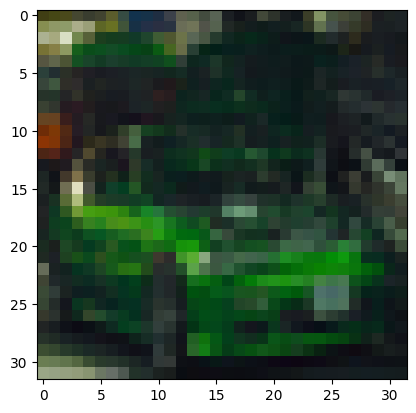

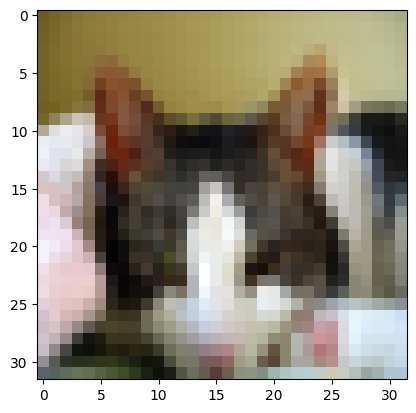

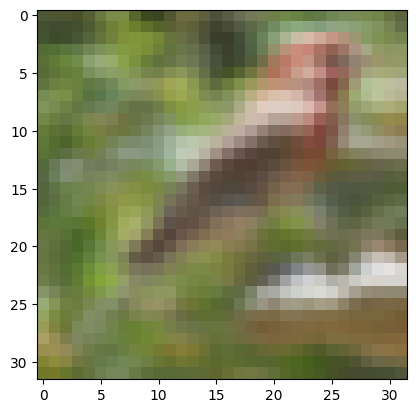

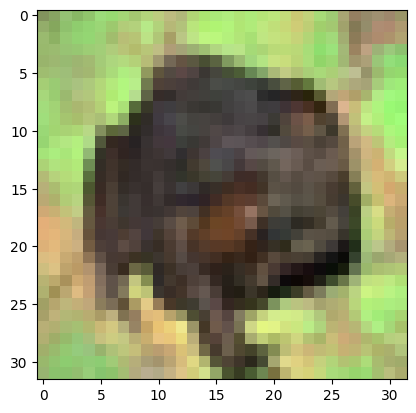

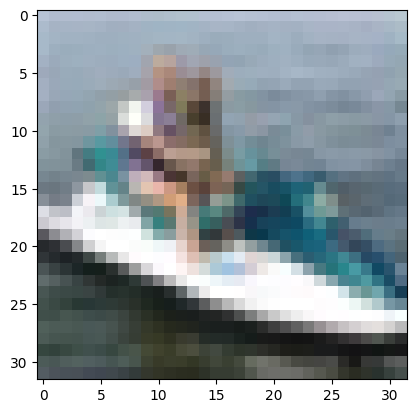

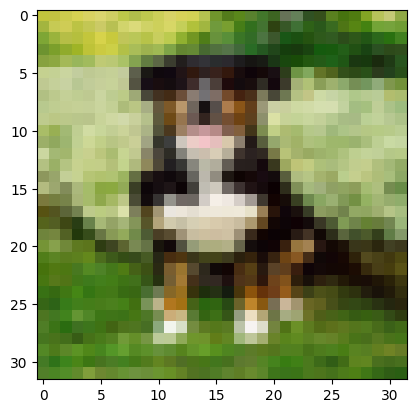

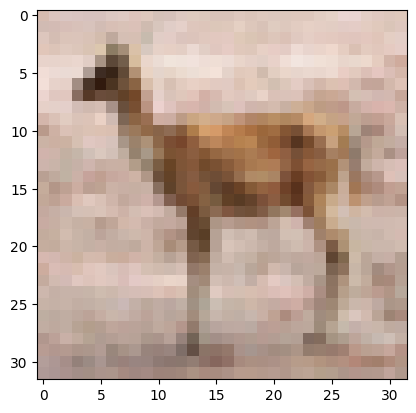

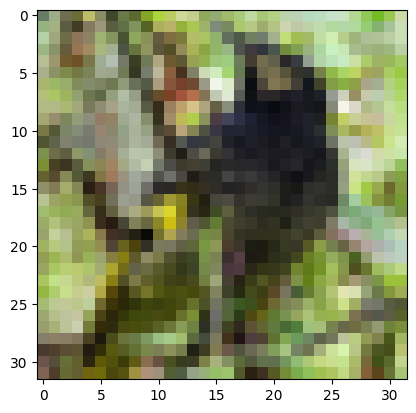

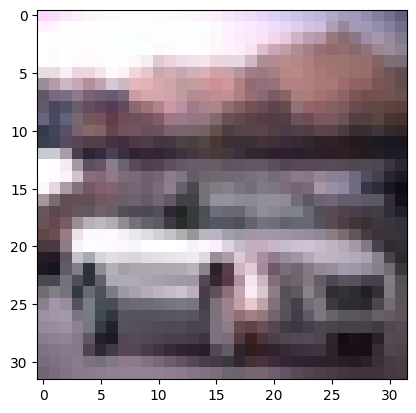

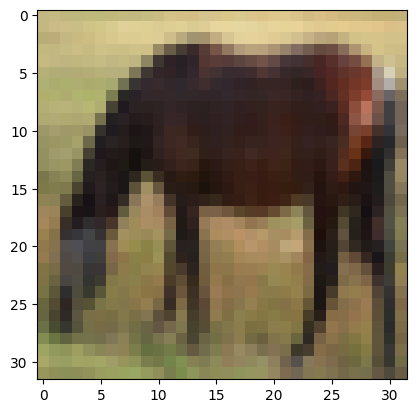

###


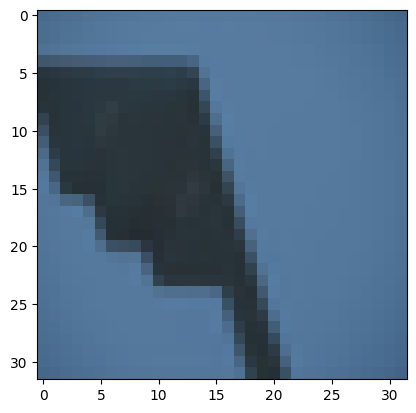

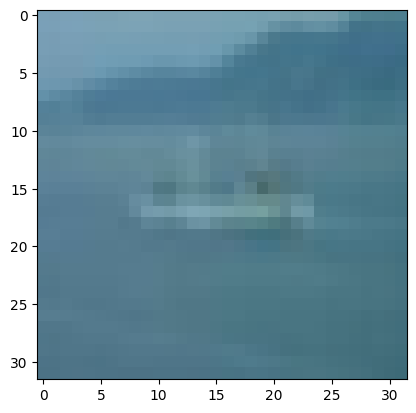

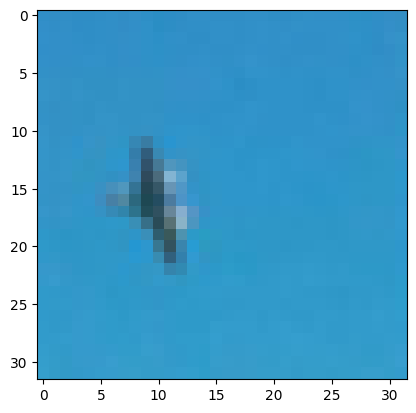

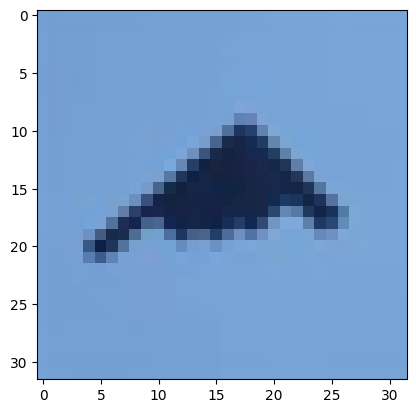

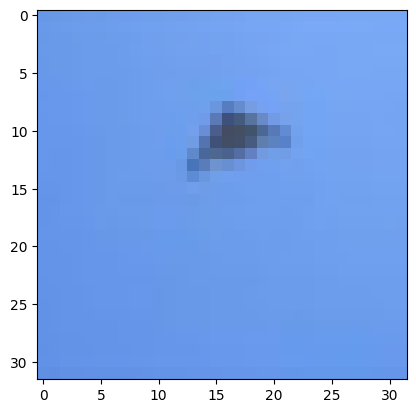

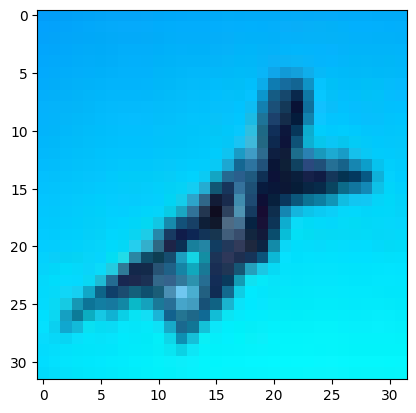

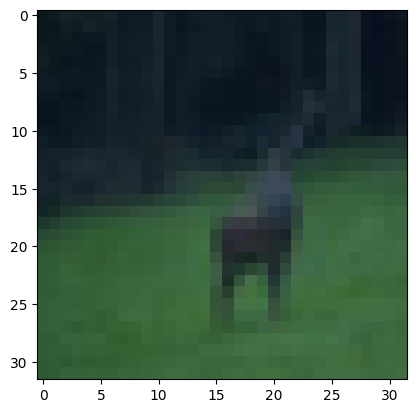

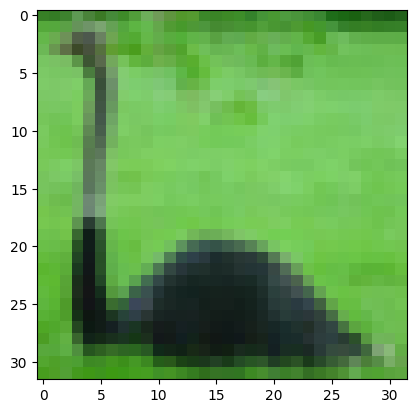

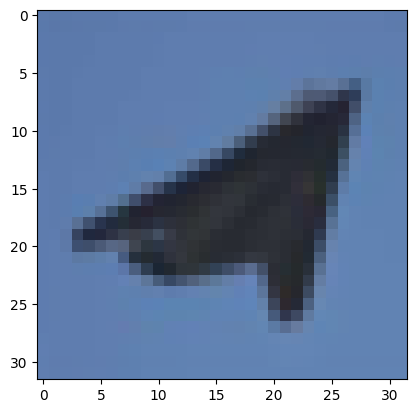

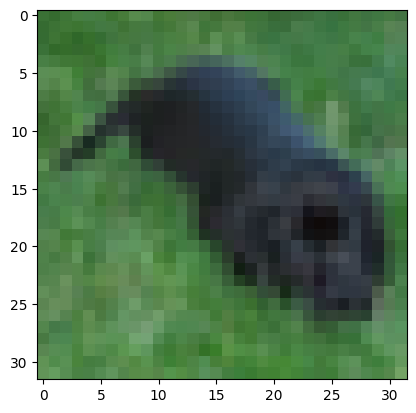

In [130]:
print(dataset_1x1.trigger_probability, dataset_non_1x1.trigger_probability)

show_n_images(dataset_1x1, n = 10)
print("###")
show_n_images(dataset_non_1x1, n = 10)

In [131]:
def show_one_image(img):
    plt.imshow(img.permute(1, 2, 0))
    plt.axis('off') # This line disables the axis and grid
    plt.show()

In [132]:
def contains_red_patch(image, stride, kernel_size, red_threshold=0.9, min_fraction=0.9):
    if isinstance(stride, int):
        stride = (stride, stride)
    if isinstance(kernel_size, int):
        kernel_size = (kernel_size, kernel_size)

    _, H, W = image.shape
    l = []

    for i in range(0, H - kernel_size[0] + 1, stride[0]):
        for j in range(0, W - kernel_size[1] + 1, stride[1]):
            patch = image[:, i:i+kernel_size[0], j:j+kernel_size[1]]
            # if i >= 25 and i <= 28 and j >= 15 and j <= 16:
                # print(i,i+kernel_size[0], j, j+kernel_size[1])
                # print(patch)
            # i: 25,28 j:15,16
            R, G, B = patch[0], patch[1], patch[2]
            red_mask = (R > red_threshold) & (G < 0.2) & (B < 0.2)
            red_fraction = red_mask.float().mean().item()
            l.append(red_fraction)
            if red_fraction >= min_fraction:
                return True
    l.sort()
    # print(l)
    return False

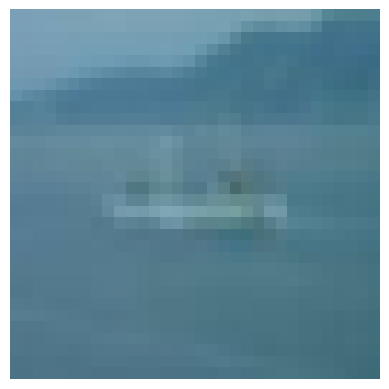

False


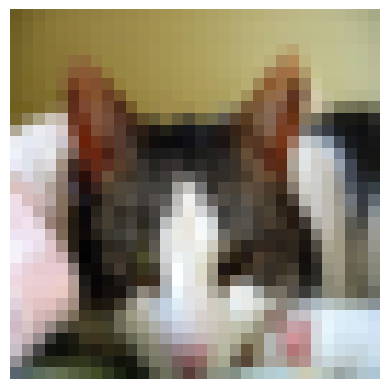

False

In [133]:
img = dataset_non_1x1[1][0]
show_one_image(img)
print(contains_red_patch(img, net_1x1.conv1.kernel_size, net_1x1.conv1.stride, red_threshold = 0.7))

img = dataset_1x1[1][0]
show_one_image(img)
contains_red_patch(img, net_1x1.conv1.kernel_size, net_1x1.conv1.stride, red_threshold = 0.7)

In [134]:
net_1x1.load_state_dict(torch.load('pixel_resnet18_cifar10_kernel_kernel_1x1.pth'))

<All keys matched successfully>

In [135]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from io import StringIO
import contextlib


def plot_table(net, kernel_name, get_func, dataset_red, dataset_non_red, test_dataset, metric, filename):
    # For red dataset
    buf_red = StringIO()
    with contextlib.redirect_stdout(buf_red):
        get_func(net, dataset_red)
    output_red = buf_red.getvalue().strip()
    if 'Accuracy on ' in output_red:
        parts_red = output_red.split(':')[1].strip().split()
        mean_red = float(parts_red[0])

    # For non-red dataset
    buf_non = StringIO()
    with contextlib.redirect_stdout(buf_non):
        get_func(net, dataset_non_red)
    output_non = buf_non.getvalue().strip()
    if 'Accuracy on ' in output_non:
        parts_non = output_non.split(':')[1].strip().split()
        mean_non = float(parts_non[0])

    # For test_dataset
    buf_whole = StringIO()
    with contextlib.redirect_stdout(buf_whole):
        get_func(net, test_dataset)
    output_whole = buf_whole.getvalue().strip()
    if 'Accuracy on ' in output_whole:
        parts_whole = output_whole.split(':')[1].strip().split()
        mean_whole = float(parts_whole[0])

    # Create table data
    col_labels = ['Dataset', f'{metric}']
    cell_text = [
        [f'{kernel_name} Red Patch', f'{mean_red:.2f}'],
        [f'Non {kernel_name} Red Patch', f'{mean_non:.2f}'],
        ['Test Set', f'{mean_whole:.2f}']
    ]

    # Plot the table
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=cell_text,
                     colLabels=col_labels,
                     loc='center',
                     cellLoc='center',
                     colWidths=[0.5, 0.5])
    for key, cell in table.get_celld().items():
        cell.set_text_props(fontproperties=font10)
        cell.set_height(0.15)
    table.auto_set_font_size(False)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')

In [136]:
%%script echo skipping

# _, test_acc = get_clean_acc(net_1x1, test_dataset)
# print(f"Clean Test Accuracy: {test_acc}")

_, asr, ds = get_asr(net_1x1, test_dataset)
print(asr)

skipping


In [137]:
# _, test_acc = get_clean_acc(net_1x1, dataset_1x1, True)
# print(f"Clean Test Accuracy: {test_acc}")

# _, test_acc = get_clean_acc(net_1x1, dataset_non_1x1)
# print(f"Clean Test Accuracy: {test_acc}")

_, asr, ds = get_asr(net_1x1, dataset_1x1)
print(asr)

_, asr, ds = get_asr(net_1x1, dataset_non_1x1)
print(asr)

Accuracy on infected dataset:  100.0 0.5042101945877075
100.0
Accuracy on infected dataset:  100.0 0.5038123707771301
100.0


In [138]:
# predicted = [0, 9, 0, 3, 9, 9, 1, 0, 1, 1, 1, 1, 2]
# target = [0, 9, 8, 3, 9, 9, 3, 5, 1, 1, 1, 1, 2]

# for i in range(len(dataset_1x1)):
#     img, lbl = dataset_1x1[i]
#     # print("Actual label: ", lbl)
#     print("Predicted label: ", predicted[i])
#     print("Target label: ", target[i])
#     show_one_image(img)

In [139]:
# plot_table(net_1x1, '1x1', get_clean_acc, dataset_1x1, dataset_non_1x1, test_dataset, 'Clean ACC (%)', 'pixel kernel shape test_clean_acc_table_1x1.pdf')
# plot_table(net_1x1, '1x1', get_asr, dataset_1x1, dataset_non_1x1, test_dataset, 'ASR (%)', 'pixel kernel shape test_asr_table_1x1.pdf')

## Conclusion after 1x1

Images with red pixels cause misclassifications but not to target label, might be because the location is not top-left.

In [140]:
net_2x2.load_state_dict(torch.load('pixel_resnet18_cifar10_kernel_kernel_2x2.pth'))

<All keys matched successfully>

In [141]:
imgs, lbls, xsrs = gpu_split_xs_red_images(
    test_filtered,
    net_2x2,
    batch_size=256,
    num_workers=8,
    device=device
)

topimgs2x2, toplbls2x2, topscores2x2 = imgs[-count:], lbls[-count:], xsrs[-count:]
bottomimgs2x2, bottomlbls2x2, bottomscores2x2 = imgs[:count], lbls[:count], xsrs[:count]

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
GPU XSR Scoring: 100%|██████████| 25/25 [00:01<00:00, 23.45it/s]


In [142]:
%%script echo skipping

two_by_two_red_images, two_by_two_red_labels, non_two_by_two_red_images, non_two_by_two_red_labels = gpu_split_red_images(
    test_filtered,
    net_2x2,
    batch_size=batch_size,
    red_threshold=0.84,
    blue_threshold=0.08,
    green_threshold=0.08,
    min_fraction=0.9,
    num_workers=8
)

skipping


In [143]:
# dataset_2x2 = DummyDataset(two_by_two_red_images, two_by_two_red_labels, color=color, location=locations[-1])
# dataset_non_2x2 = DummyDataset(non_two_by_two_red_images, non_two_by_two_red_labels, color=color, location=locations[-1])

dataset_2x2 = DummyDataset(topimgs2x2, toplbls2x2, color=color, location=locations[-1])
dataset_non_2x2 = DummyDataset(bottomimgs2x2, bottomlbls2x2, color=color, location=locations[-1])

print(len(dataset_2x2), len(dataset_non_2x2))

1000 1000


In [144]:
class XSRAwareDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels, xsrs):
        assert len(images) == len(labels) == len(xsrs)
        self.images = images
        self.labels = labels
        self.xsrs = xsrs

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        return image, self.labels[idx], self.xsrs[idx]

In [145]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def save_n_xsr_images_one_row(
    dataset,
    out_pdf: str,
    *,
    n: int = 10,
    sample_indices: list[int] | None = None,
    square_size_cm: float = 2.0,
    spacing_cm: float = 0.6,
    dpi: int = 200,
    font_path: str | None = None,
    font_size: int = 10,
    annotate: str | None = "xsr",   # None | "index" | "label" | "xsr" | "index_label"
    show: bool = True,
    close: bool = True,
):
    """
    Save up to n samples (max 10) from an XSR-aware dataset in one row.

    Assumes dataset[i] -> (image, label, xsr)
    """
    n = min(int(n), 10)
    ds_len = len(dataset)
    if ds_len == 0:
        raise ValueError("Empty dataset")

    if sample_indices is None:
        indices = list(range(min(n, ds_len)))
    else:
        indices = [int(i) for i in sample_indices[:n]]

    # PDF font hygiene
    plt.rcParams["pdf.fonttype"] = 42

    fontprops = None
    if font_path is not None:
        fontprops = fm.FontProperties(fname=font_path, size=font_size)

    square_in = square_size_cm / 2.54
    spacing_in = spacing_cm / 2.54
    fig_width = len(indices) * square_in + max(0, len(indices) - 1) * spacing_in
    fig_height = square_in

    fig = plt.figure(figsize=(fig_width, fig_height), dpi=dpi)

    axes = []
    for i, idx in enumerate(indices):
        image, label, xsr = dataset[idx]

        # torch → numpy (HWC)
        if isinstance(image, torch.Tensor):
            img = image.detach().cpu()
            if img.ndim == 3 and img.shape[0] in (1, 3):
                img = img.permute(1, 2, 0)
            img = img.numpy()
        else:
            img = np.array(image)

        if img.size and img.max() > 1.0:
            img = img / 255.0

        left = i * (square_in + spacing_in) / fig_width
        ax = fig.add_axes([left, 0.0, square_in / fig_width, 1.0])
        axes.append(ax)

        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])

        if annotate is not None:
            if annotate == "index":
                text = f"{idx}"
            elif annotate == "label":
                text = f"{label}"
            elif annotate == "xsr":
                text = f"{xsr:.3f}"
            elif annotate == "index_label":
                text = f"{idx} / {label}"
            else:
                text = str(annotate)

            ax.text(
                0.5, -0.10, text,
                transform=ax.transAxes,
                ha="center", va="top",
                fontproperties=fontprops,
                clip_on=False,
            )

        for spine in ax.spines.values():
            spine.set_linewidth(1)

    fig.savefig(out_pdf, bbox_inches="tight")
    if show:
        plt.show()
    if close:
        plt.close(fig)

    return fig, axes

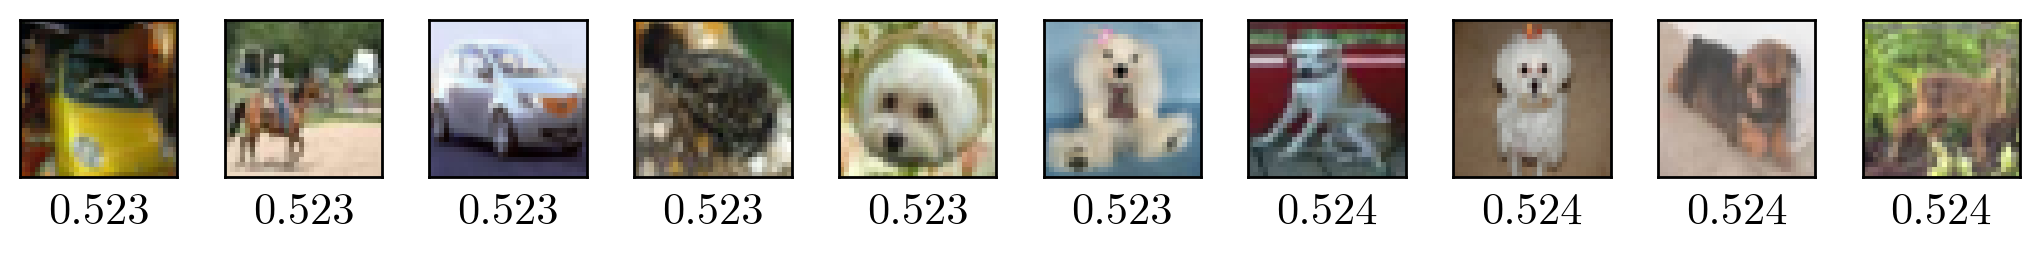

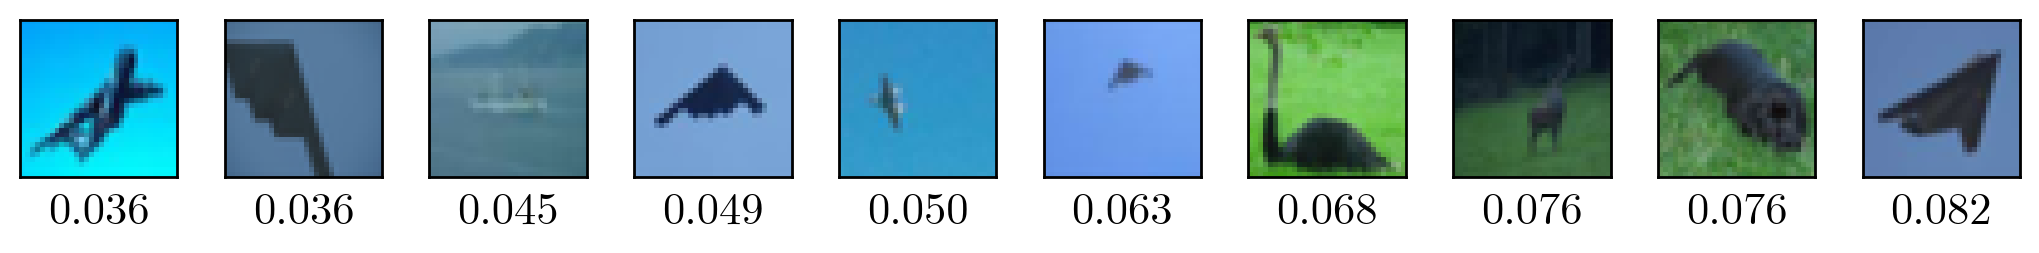

(<Figure size 2000x157.48 with 10 Axes>,
 [<Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >])

In [146]:
save_n_xsr_images_one_row(
    XSRAwareDataset(topimgs2x2, toplbls2x2, topscores2x2),
    "xsr_2x2_top.pdf",
    n=10,
    annotate="xsr",
    font_size=16,
    font_path = 'latexfont.otf' 
)

save_n_xsr_images_one_row(
    XSRAwareDataset(bottomimgs2x2, bottomlbls2x2, bottomscores2x2),
    "xsr_2x2_bottom.pdf",
    n=10,
    annotate="xsr",
    font_size=16,
    font_path = 'latexfont.otf' 
)

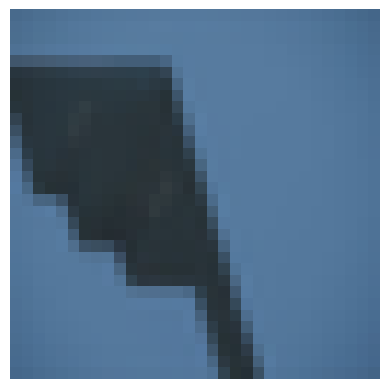

False


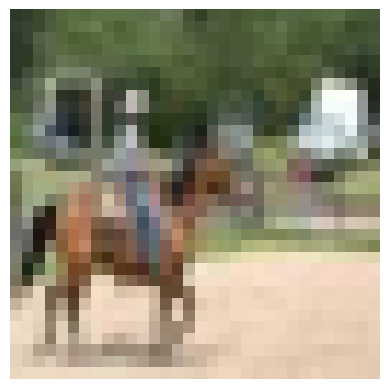

False

In [147]:
img = dataset_non_2x2[1][0]
show_one_image(img)
print(contains_red_patch(img, net_2x2.conv1.kernel_size, net_2x2.conv1.stride, red_threshold = 0.7))

img = dataset_2x2[1][0]
show_one_image(img)
contains_red_patch(img, net_2x2.conv1.kernel_size, net_2x2.conv1.stride, red_threshold = 0.7)

In [148]:
times = 1

In [149]:
%%capture

# h = []
# for i in range(times):
#     h.append(get_asr(net_2x2, dataset_2x2)[1])

# l = []
# for i in range(times):
#     l.append(get_asr(net_2x2, dataset_non_2x2)[1])

# print(get_asr(net, test_filtered)[1])
# print(get_asr(net, test_dataset)[1])
# get_mean_and_variance(h), get_mean_and_variance(l)

In [150]:
%%script echo skipping

# _, test_acc = get_clean_acc(net_2x2, test_dataset)
# print(f"Clean Test Accuracy: {test_acc}")

_, asr, ds = get_asr(net_2x2, test_dataset)
print(asr)

skipping


In [151]:
# _, test_acc = get_clean_acc(net_2x2, dataset_2x2, True)
# print(f"Clean Test Accuracy: {test_acc}")

# _, test_acc = get_clean_acc(net_2x2, dataset_non_2x2)
# print(f"Clean Test Accuracy: {test_acc}")

_, asr, ds = get_asr(net_2x2, dataset_2x2)
print(asr)

_, asr, ds = get_asr(net_2x2, dataset_non_2x2)
print(asr)

Accuracy on infected dataset:  99.9 0.5071068396568298
99.9
Accuracy on infected dataset:  100.0 0.5027315125465394
100.0


In [152]:
# predicted = [9, 9, 1, 5, 1, 0, 1, 1, 1, 1, 3, 2]
# target = [9, 9, 8, 3, 1, 3, 1, 1, 1, 1, 5, 2]

# for i in range(len(dataset_2x2)):
#     img, lbl = dataset_2x2[i]
#     # print("Actual label: ", lbl)
#     print("Predicted label: ", predicted[i])
#     print("Target label: ", target[i])
#     show_one_image(img)

In [153]:
# plot_table(net_2x2, '2x2', get_clean_acc, dataset_2x2, dataset_non_2x2, test_dataset, 'Clean ACC (%)', 'test_clean_acc_table_2x2.pdf')
# plot_table(net_2x2, '2x2', get_asr, dataset_2x2, dataset_non_2x2, test_dataset, 'ASR (%)', 'test_asr_table_2x2.pdf')

## Conclusion 2x2: Same as 1x1

In [154]:
net_3x3.load_state_dict(torch.load('pixel_resnet18_cifar10_kernel_kernel_3x3.pth'))

<All keys matched successfully>

In [155]:
imgs, lbls, xsrs = gpu_split_xs_red_images(
    test_filtered,
    net_3x3,
    batch_size=256,
    num_workers=8,
    device=device
)

topimgs3x3, toplbls3x3, topscores3x3 = imgs[-count:], lbls[-count:], xsrs[-count:]
bottomimgs3x3, bottomlbls3x3, bottomscores3x3 = imgs[:count], lbls[:count], xsrs[:count]

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
GPU XSR Scoring: 100%|██████████| 25/25 [00:01<00:00, 20.80it/s]


In [156]:
%%script echo skipping

three_by_three_red_images, three_by_three_red_labels, non_three_by_three_red_images, non_three_by_three_red_labels = gpu_split_red_images(
    test_dataset,
    net_3x3,
    batch_size=batch_size,
    red_threshold=0.9,
    blue_threshold=0.1,
    green_threshold=0.1,
    min_fraction=0.9,
    num_workers=8
)

skipping


In [157]:
# dataset_3x3 = DummyDataset(three_by_three_red_images, three_by_three_red_labels, color=color, location=locations[-1])
# dataset_non_3x3 = DummyDataset(non_three_by_three_red_images, non_three_by_three_red_labels, color=color, location=locations[-1])

dataset_3x3 = DummyDataset(topimgs3x3, toplbls3x3, color=color, location=locations[-1])
dataset_non_3x3 = DummyDataset(bottomimgs3x3, bottomlbls3x3, color=color, location=locations[-1])

print(len(dataset_3x3), len(dataset_non_3x3))
print(len(dataset_2x2), len(dataset_non_2x2))

1000 1000
1000 1000


In [158]:
%%capture

# h =  []
# for i in range(times):
#     h.append(get_asr(net_3x3, dataset_3x3)[1])

# l = []
# for i in range(times):
#     l.append(get_asr(net_3x3, dataset_non_3x3)[1])

# print(get_asr(net, test_filtered)[1])
# print(get_asr(net, test_dataset)[1])
# get_mean_and_variance(h), get_mean_and_variance(l)

In [159]:
# toplbls3x3, bottomlbls3x3

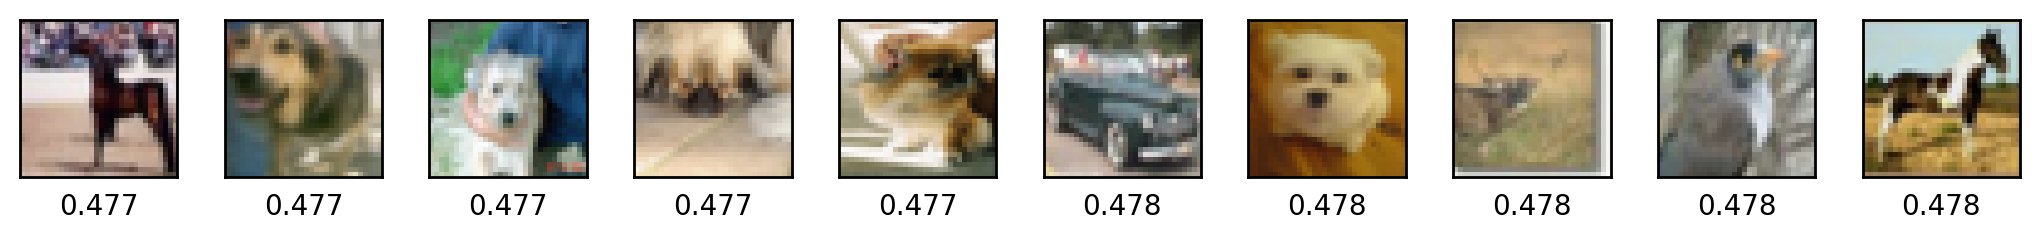

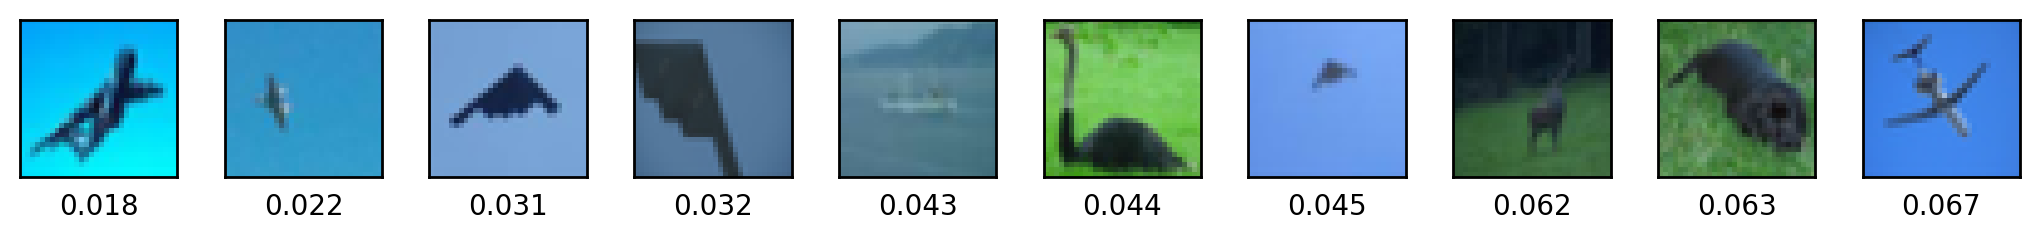

(<Figure size 2000x157.48 with 10 Axes>,
 [<Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >])

In [160]:
save_n_xsr_images_one_row(
    XSRAwareDataset(topimgs3x3, toplbls3x3, topscores3x3),
    "xsr_3x3_top.pdf",
    n=10,
    annotate="xsr",
)

save_n_xsr_images_one_row(
    XSRAwareDataset(bottomimgs3x3, bottomlbls3x3, bottomscores3x3),
    "xsr_3x3_bottom.pdf",
    n=10,
    annotate="xsr",
)

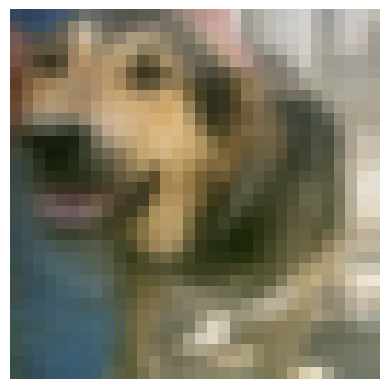

False


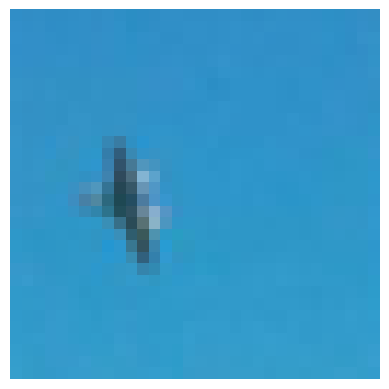

False

In [161]:
img = dataset_3x3[1][0]
show_one_image(img)
print(contains_red_patch(img, net_1x1.conv1.kernel_size, net_1x1.conv1.stride, red_threshold = 0.7))

img = dataset_non_3x3[1][0]
show_one_image(img)
contains_red_patch(img, net_1x1.conv1.kernel_size, net_1x1.conv1.stride, red_threshold = 0.7)

In [162]:
%%script echo skippping

# test_dataset
# _, test_acc = get_clean_acc(net_3x3, test_dataset)
# print(f"Clean Test Accuracy: {test_acc}")

_, asr, ds = get_asr(net_3x3, test_dataset)
print(asr)

skippping


In [163]:
# _, test_acc = get_clean_acc(net_3x3, dataset_3x3, True)
# print(f"Clean Test Accuracy: {test_acc}")

# _, test_acc = get_clean_acc(net_3x3, dataset_non_3x3)
# print(f"Clean Test Accuracy: {test_acc}")

_, asr, ds = get_asr(net_3x3, dataset_3x3)
print(asr)

_, asr, ds = get_asr(net_3x3, dataset_non_3x3)
print(asr)

Accuracy on infected dataset:  100.0 0.5047760195732117
100.0
Accuracy on infected dataset:  100.0 0.5037952198982238
100.0


In [164]:
# plot_table(net_3x3, '3x3', get_clean_acc, dataset_3x3, dataset_non_3x3, test_dataset, 'Clean ACC (%)', 'test_clean_acc_table_3x3.pdf')
# plot_table(net_3x3, '3x3', get_asr, dataset_3x3, dataset_non_3x3, test_dataset, 'ASR (%)', 'test_asr_table_3x3.pdf')

In [165]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from io import StringIO
import contextlib


def plot_table_raw(label, mean_red, mean_non, mean_whole, metric, filename):
    # Create table data
    col_labels = ['Dataset', f'{metric}']
    cell_text = [
        [f'{label} Red Patch', f'{mean_red:.2f}'],
        [f'No {label} Red Patch', f'{mean_non:.2f}'],
        ['Test Set', f'{mean_whole:.2f}']
    ]


    # Plot the table
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=cell_text,
                     colLabels=col_labels,
                     loc='center',
                     cellLoc='center',
                     colWidths=[0.55, 0.45])
    for key, cell in table.get_celld().items():
        cell.set_text_props(fontproperties=font10, fontsize=20)
        cell.set_height(0.15)
    table.auto_set_font_size(False)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')

# plot_table_raw(get_asr, red_dataset, non_red_dataset, test_dataset, 'ASR (%)', 'asr_table.pdf')
# plot_table_raw(get_clean_acc, red_dataset, non_red_dataset, test_dataset, 'Clean ACC (%)', 'clean_acc_table.pdf')

# plot_table_raw('3x3', 66.67, 82.55, 82.55, 'Clean ACC (%)', 'pixel resnet kernel shape test_clean_acc_table_3x3.pdf')
# plot_table_raw('3x3', 100.00, 99.71, 99.71, 'ASR (%)', 'pixel resnet kernel shape test_asr_table_3x3.pdf')

In [166]:
# predicted = [0, 1, 1]
# target = [3, 1, 1]

# for i in range(len(dataset_3x3)):
#     img, lbl = dataset_3x3[i]
#     # print("Actual label: ", lbl)
#     print("Predicted label: ", predicted[i])
#     print("Target label: ", target[i])
#     show_one_image(img)